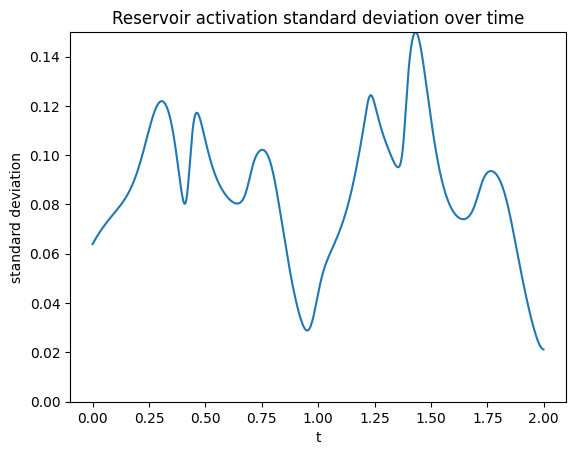

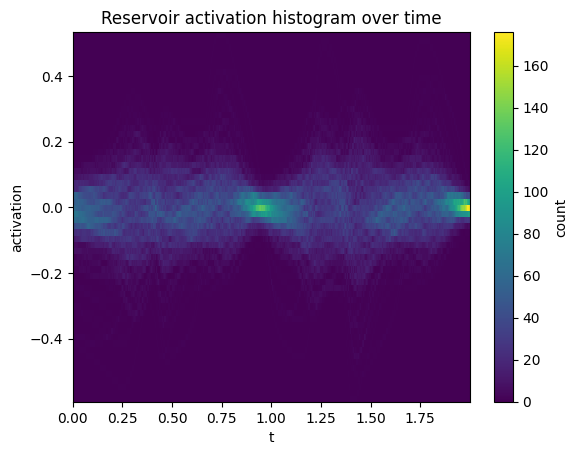

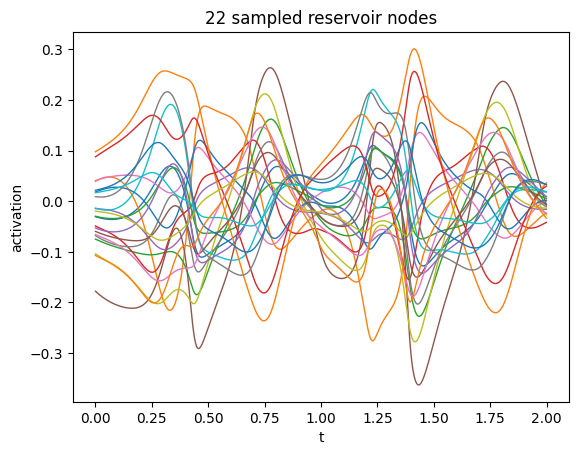

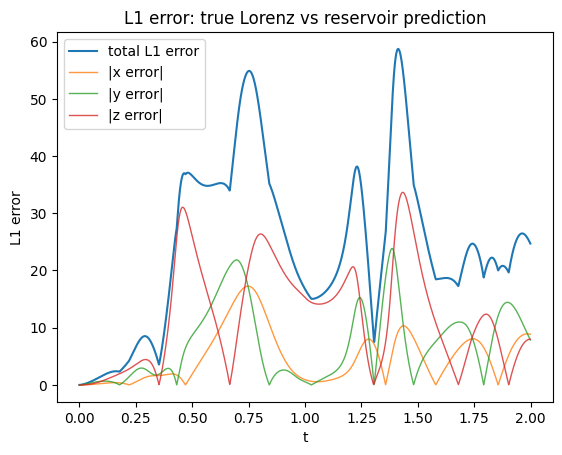

In [1]:
from connectome import *

file_path = Path("100206_repeated10_scale250.graphml")
dt = 0.001

W, W_in, W_out, r_last, U_mean, U_std, lorenz_start, lorenz_cfg = setup_reservoir(
    file_path,
    J=1,
    dt=dt,
    washout_time=1000 * dt,   # 1.0
    train_time=20000 * dt,    # 20.0
    input_scale=0.03,
    lambda_reg=1e-5,
)

samples, Y_std = run_reservoir(
    W, W_in, W_out, r_last,
    duration=2000 * dt,       # 2.0
    dt=dt,
)

T = samples.shape[0] * dt

# reservoir prediction in original Lorenz coordinates
Y = Y_std * U_std + U_mean

# true Lorenz continuation from the exact matching state
Y_true, _ = lorenz_trajectory(
    duration=T,
    dt=lorenz_cfg["dt"],
    x0=lorenz_start,
    sigma=lorenz_cfg["sigma"],
    rho=lorenz_cfg["rho"],
    beta=lorenz_cfg["beta"],
)

plot_state_std(samples, t=T)
plt.show()

plot_state_sand(samples, t=T, n_bins=60)
plt.show()

plot_sampled_nodes(samples, t=T, n=22, rng=0)
plt.show()

plot_lorenz_l1_error(Y, Y_true, t=T, per_dimension=True)
plt.show()